# Hand Written text recognition using CNN + Bidirectional LSTM + CTC Loss

### Importing Libraries

In [3]:
import torch
torch.cuda.empty_cache()

In [4]:
from datasets import load_dataset
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

### Import Dataset

In [6]:
ds = load_dataset("Teklia/IAM-line")

In [7]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})

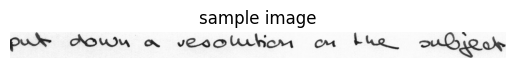

text: put down a resolution on the subject


In [8]:
#Sample Image
sample = ds["train"][0]
img = sample["image"]    
text = sample["text"]      

plt.imshow(img, cmap="gray")
plt.title("sample image")
plt.axis("off")
plt.show()

print("text:", text)

### Build Vocabulary

In [10]:
def build_vocab(dataset):
    charset = set()
    for text in dataset["text"]:
        charset.update(list(text))
    charset = sorted(list(charset))
    vocab = {ch: i+1 for i, ch in enumerate(charset)} 
    vocab["<BLANK>"] = 0
    return vocab


In [11]:
vocab = build_vocab(ds["train"])

vocab_inv = {v: k for k, v in vocab.items()}

print("Vocab size:", len(vocab))
print("Sample mapping:", dict(list(vocab.items())[:10]))

Vocab size: 80
Sample mapping: {' ': 1, '!': 2, '"': 3, '#': 4, '&': 5, "'": 6, '(': 7, ')': 8, '*': 9, '+': 10}


In [12]:
def encode_text(text):
    return [vocab[ch] for ch in text]

### Build Dataset

In [14]:
IMG_HEIGHT = 32

def preprocess_image_to_tensor(pil_image, img_height=IMG_HEIGHT):

    img = np.array(pil_image)
    if img.ndim == 3: 
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img = img.astype(np.float32) / 255.0

    # Resize keeping aspect ratio to fixed height
    h, w = img.shape
    new_w = max(1, int(round(w * (img_height / h))))
    img = cv2.resize(img, (new_w, img_height), interpolation=cv2.INTER_AREA)

    tensor = torch.from_numpy(img).unsqueeze(0)
    return tensor

In [15]:
class IAMLineDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, img_height=IMG_HEIGHT):
        self.data = hf_dataset
        self.img_height = img_height

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img_tensor = preprocess_image_to_tensor(sample["image"], self.img_height)
        label = encode_text(sample["text"])
        return img_tensor, torch.tensor(label, dtype=torch.long)

In [16]:
def collate_fn(batch):
    images, labels = zip(*batch)
    
    max_w = max(img.shape[2] for img in images) #max width in batch

    padded_images = []
    for img in images:
        pad_w = max_w - img.shape[2]
        if pad_w > 0:
            img = torch.nn.functional.pad(img, (0, pad_w), value=0.0)  # pad right
        padded_images.append(img)

    images_tensor = torch.stack(padded_images)  # [B, 1, H, max_W]
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_concat = torch.cat(labels)

    img_lengths = torch.full(size=(len(images),), fill_value=max_w, dtype=torch.long)

    return images_tensor, labels_concat, img_lengths, label_lengths

In [17]:

train_dataset = IAMLineDataset(ds["train"])
val_dataset = IAMLineDataset(ds["validation"])
test_dataset = IAMLineDataset(ds["test"])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True,collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True,collate_fn=collate_fn)

images, labels_concat, img_lengths, label_lengths = next(iter(train_loader))
print("Images batch shape:", images.shape)  # [B, 1, H, W]
print("Labels concat shape:", labels_concat.shape)
print("Image lengths:", img_lengths)
print("Label lengths:", label_lengths)

Images batch shape: torch.Size([16, 1, 32, 602])
Labels concat shape: torch.Size([721])
Image lengths: tensor([602, 602, 602, 602, 602, 602, 602, 602, 602, 602, 602, 602, 602, 602,
        602, 602])
Label lengths: tensor([49, 43, 44, 64, 44, 41, 29, 45, 41, 29, 40, 44, 57, 55, 43, 53])


### Model

In [19]:
class CRNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        # CNN 
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 128, 3, 1, 1), 
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),         

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),

            nn.Conv2d(512, 512, 2, 1, 0),
            nn.ReLU(inplace=True), 
        )

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        self.fc = nn.Linear(512, num_classes)  # 256*2

    def forward(self, x):
        feats = self.cnn(x)               # [B, C, Hc, Wc]
        B, C, Hc, Wc = feats.size()

        # Force height collapse if not exactly 1 (average over height)
        if Hc != 1:
            feats = feats.mean(dim=2, keepdim=True)  # [B, C, 1, Wc]

        feats = feats.squeeze(2)          # [B, C, Wc]
        feats = feats.permute(0, 2, 1)    # [B, Wc, C]  -> sequence length = Wc

        rnn_out, _ = self.rnn(feats)      # [B, Wc, 512]
        logits = self.fc(rnn_out)         # [B, Wc, num_classes]
        log_probs = F.log_softmax(logits, dim=-1)

        input_lengths = torch.full((B,), logits.size(1), dtype=torch.long, device=logits.device)
        return logits, log_probs, input_lengths



In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [21]:
num_classes = len(vocab) 
model = CRNN(num_classes=num_classes).to(device)
ctc_loss_fn = nn.CTCLoss(blank=0, reduction="mean", zero_infinity=True) 

In [22]:
#loss calculation for one batch
images, labels_concat, img_lengths, label_lengths = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    logits, log_probs, input_lengths = model(images)      
    print("logits shape:", logits.shape)                  
    print("CTC input lengths (T):", input_lengths)

log_probs_tbc = log_probs.permute(1, 0, 2).contiguous()

# Compute a test loss 
loss = ctc_loss_fn(log_probs_tbc, labels_concat.to(device), input_lengths, label_lengths.to(device))
print("loss for one batch:", float(loss))

logits shape: torch.Size([16, 190, 80])
CTC input lengths (T): tensor([190, 190, 190, 190, 190, 190, 190, 190, 190, 190, 190, 190, 190, 190,
        190, 190], device='cuda:0')
loss for one batch: 16.43548011779785


### Train and Validate

In [24]:
# cer loss function
import editdistance
def cer(pred, gt):
    """Compute Character Error Rate (edit distance / length)."""
    return editdistance.eval(pred, gt) / max(len(gt), 1)


In [25]:

# validation function
def validate(model, val_loader, ctc_loss_fn, vocab_inv, device):
    model.eval()
    total_loss, total_cer = 0.0, 0.0
    count = 0

    with torch.no_grad():
        for images, labels_concat, img_lengths, label_lengths in val_loader:
            images = images.to(device)
            labels_concat = labels_concat.to(device)
            img_lengths = img_lengths.to(device)
            label_lengths = label_lengths.to(device)

            # Forward
            logits, log_probs, input_lengths = model(images)
            log_probs_tbc = log_probs.permute(1, 0, 2)  # [T, B, C]

            # Loss
            loss = ctc_loss_fn(log_probs_tbc, labels_concat, input_lengths, label_lengths)
            total_loss += loss.item()

            # Decode
            pred_texts = greedy_decode(log_probs, vocab_inv)

            # Ground truth texts
            gt_texts = []
            start = 0
            for l in label_lengths:
                label_seq = labels_concat[start:start+l]
                gt_texts.append("".join(vocab_inv[i.item()] for i in label_seq))
                start += l

            # CER per sample
            for p, g in zip(pred_texts, gt_texts):
                total_cer += cer(p, g)
                count += 1

    avg_loss = total_loss / len(val_loader)
    avg_cer = total_cer / count
    return avg_loss, avg_cer


In [26]:
#Decoding function
def greedy_decode(log_probs, vocab_inv):
    """
    log_probs: [B, T, C] after log_softmax
    vocab_inv: dict idx->char
    """
    preds = log_probs.argmax(dim=-1).cpu().numpy()  # [B, T]
    texts = []
    for seq in preds:
        prev = -1
        chars = []
        for idx in seq:
            if idx != prev and idx != 0:  # skip repeats and blank=0
                chars.append(vocab_inv[idx])
            prev = idx
        texts.append("".join(chars))
    return texts



In [27]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) 
ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)

EPOCHS = 50
train_losses=[]
val_losses=[]
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for images, labels_concat, img_lengths, label_lengths in train_loader:
        images = images.to(device)
        labels_concat = labels_concat.to(device)
        img_lengths = img_lengths.to(device)
        label_lengths = label_lengths.to(device)

        optimizer.zero_grad()

        logits, log_probs, input_lengths = model(images)
        log_probs_tbc = log_probs.permute(1, 0, 2) 
        
        loss = ctc_loss_fn(log_probs_tbc, labels_concat, input_lengths, label_lengths)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / len(train_loader)
    
    train_losses.append(avg_loss)
   # validation
    val_loss, val_cer = validate(model, val_loader, ctc_loss_fn, vocab_inv, device)
    val_losses.append(val_loss)
    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {avg_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | CER: {val_cer:.4f}")


    # show some predictions
    model.eval()
    with torch.no_grad():
        images, labels_concat, img_lengths, label_lengths = next(iter(val_loader))
        images = images.to(device)
        logits, log_probs, input_lengths = model(images)
        pred_texts = greedy_decode(log_probs, vocab_inv)

        gt_texts = []
        start = 0
        for l in label_lengths:
            label_seq = labels_concat[start:start+l]
            gt_texts.append("".join(vocab_inv[i.item()] for i in label_seq))
            start += l

        print("\n--- Sample Predictions ---")
        for i in range(min(5, len(pred_texts))):  
            print(f"original : {gt_texts[i]}")
            print(f"Pred: {pred_texts[i]}\n")
      


[Epoch 1] Train Loss: 3.3105 | Val Loss: 3.2099 | CER: 1.0000

--- Sample Predictions ---
original : said her say Peggy manfully shouldered her
Pred: 

original : with our mental state as with our physical exhaustion . A
Pred: 

original : is established . Ifor Huw Evans , Propr. ,
Pred: 

original : That little beast , Robbie Munyard ! " Having
Pred: 

original : A little more honesty , even if one refrains from going into
Pred: 

[Epoch 2] Train Loss: 3.1692 | Val Loss: 3.1681 | CER: 0.9957

--- Sample Predictions ---
original : she blow some more . " " Hello , Willie , where
Pred: 

original : realised it was important enough for her to have remembered , and it
Pred: 

original : The word is a Persian loan-word ,
Pred: 

original : have married a parson . " He kissed her . " Parsons
Pred: 

original : that one of us must volunteer . The Bishop , Dr. Burge , did
Pred: 

[Epoch 3] Train Loss: 3.1559 | Val Loss: 3.1716 | CER: 0.9870

--- Sample Predictions ---
original : I had a distin

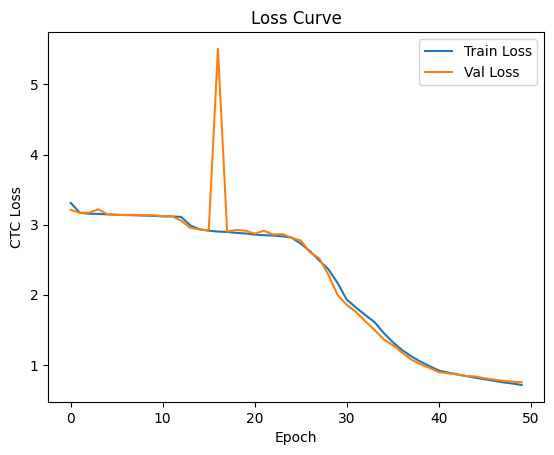

In [28]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()


In [29]:
torch.save(model.state_dict(), "crnn_model1.pth")

In [30]:
# Load model later
num_classes = len(vocab) 
model = CRNN(num_classes=num_classes)  # initialize the same architecture
model.load_state_dict(torch.load("crnn_model.pth"))
model.to(device)
model.eval()

CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (13): Conv2d(512, 512, kernel_size=(2, 2), stride=(1, 1))
    (14): ReLU(inplace=True)
  )
  (rnn): LS

In [31]:
def predict_single_image(model, test_img, vocab_inv, device, img_height=32):
    model.eval()

    # Load image
    # pil_img = Image.open(image_path).convert("RGB")  # keep it consistent
    tensor_img = preprocess_image_to_tensor(test_img, img_height=img_height)  # [1, H, W]
    tensor_img = tensor_img.unsqueeze(0).to(device)  # [B=1, 1, H, W]

    with torch.no_grad():
        logits, log_probs, input_lengths = model(tensor_img)  # forward pass

        # Greedy decode (same as in training)
        pred_texts = greedy_decode(log_probs, vocab_inv)

    return pred_texts[0]




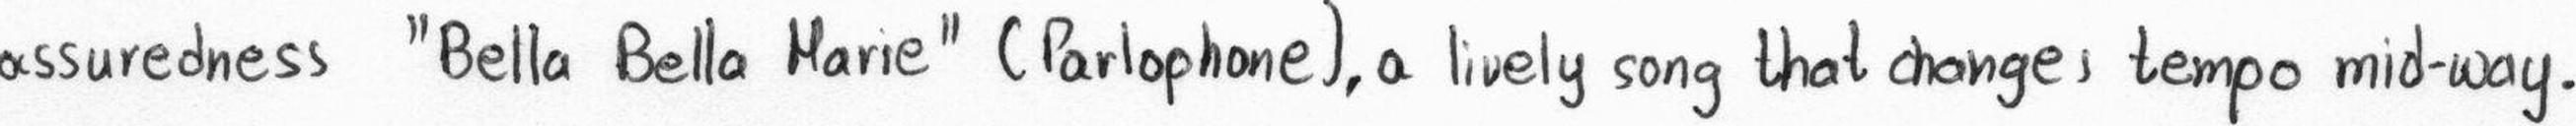

In [32]:
test_img=ds["test"][0]["image"]
test_img

In [33]:

# --- Example usage ---
# test_image = "sample.png"  # change this to your test image path
pred_text = predict_single_image(model, test_img, vocab_inv, device)
print("Predicted text:", pred_text)

Predicted text: assurechess " Bella Bella Marie " C Parlophane ), 0 lively song thal crange s tempo mid wy ,
